Murali Krishna Vattikunta

Advanced Big Data and Data Mining

Lab 4: Linear, Multiple, Polynomial, Ridge, and Lasso Regression Using the Diabetes Dataset

In [1]:
# importing required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes

In [2]:
# Load dataset

diabetes = load_diabetes()

# Create DataFrame

X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)

y = pd.Series(diabetes.target, name='Disease_Progression')

# Display first 5 rows

X.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [3]:
#Exploring dataset information

print("Feature Names:")

print(diabetes.feature_names)

print("\nDataset Shape:")

print(X.shape)

print("\nTarget Shape:")

print(y.shape)

Feature Names:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Dataset Shape:
(442, 10)

Target Shape:
(442,)


In [4]:
#Statistics summary

X.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01


In [5]:
#checking for missing values

print(X.isnull().sum())

print("\nMissing Values in Target:")

print(y.isnull().sum())

age    0
sex    0
bmi    0
bp     0
s1     0
s2     0
s3     0
s4     0
s5     0
s6     0
dtype: int64

Missing Values in Target:
0


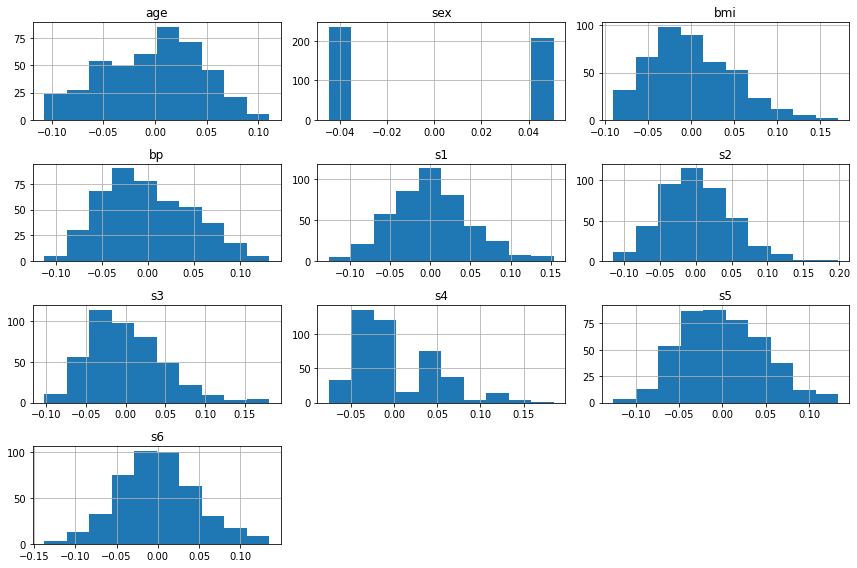

In [6]:
#Data Distribution Visualization

#Histograms

X.hist(figsize=(12,8))

plt.tight_layout()

plt.show()

#This will visualize the distribution of each feature.

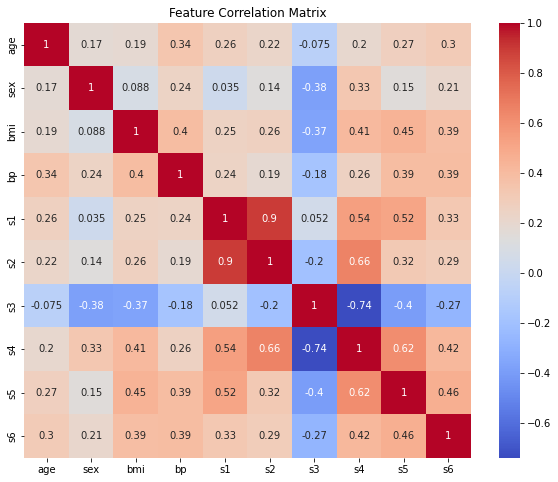

In [7]:
# Correlation Heatmap

plt.figure(figsize=(10,8))

sns.heatmap(X.corr(), annot=True, cmap='coolwarm')

plt.title("Feature Correlation Matrix")

plt.show()

#This shows relationships among predictor variables.

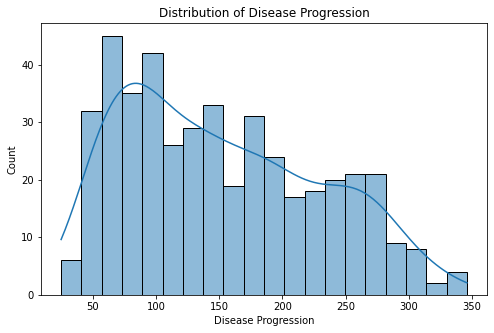

In [8]:
#Target Variable Distribution

plt.figure(figsize=(8,5))

sns.histplot(y, bins=20, kde=True)

plt.title("Distribution of Disease Progression")

plt.xlabel("Disease Progression")

plt.show()

## Data Preparation Analysis

For this project, I used the Diabetes dataset. It has data for 442 patients and 10 features like age, BMI, blood pressure, and blood test reports. Our main goal is to predict how much the disease has increased after one year.

The best part? The data was already very clean. There were absolutely no missing values, so I didn't have to do any extra cleaning work. Also, looking at the summary statistics, all the features were already scaled and centered around zero, so that saved a lot of time.

Next, I checked the histograms and found that most features follow a normal, bell-shaped distribution. I also created a correlation heatmap to see how the variables are connected. There are some decent connections between the features, which means a multiple regression model will work quite well here. Finally, the target variable is smooth and continuous, so it is perfect for regression analysis.

# Step 2: Simple Linear Regression

In [9]:
# importing required libraries

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import numpy as np

In [10]:
#We’ll use BMI as the independent variable.

# Independent variable

X_simple = X[['bmi']]

# Dependent variable

y = diabetes.target

In [11]:
#Splitting the dataset

X_train, X_test, y_train, y_test = train_test_split(

    X_simple,

    y,

    test_size=0.2,

    random_state=42

)

In [12]:
#Training the linear regression model

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
# Making predictions

y_pred = linear_model.predict(X_test)

In [14]:
# Evaluating the model

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Model Performance")

print("----------------------------")

print(f"Mean Absolute Error (MAE): {mae:.2f}")

print(f"Mean Squared Error (MSE): {mse:.2f}")

print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

print(f"R-squared (R²): {r2:.2f}")

Model Performance
----------------------------
Mean Absolute Error (MAE): 52.26
Mean Squared Error (MSE): 4061.83
Root Mean Squared Error (RMSE): 63.73
R-squared (R²): 0.23


In [15]:
# Displaying Regression Equation

print("Intercept:", linear_model.intercept_)

print("Slope:", linear_model.coef_[0])

Intercept: 152.00335421448167
Slope: 998.577689137559


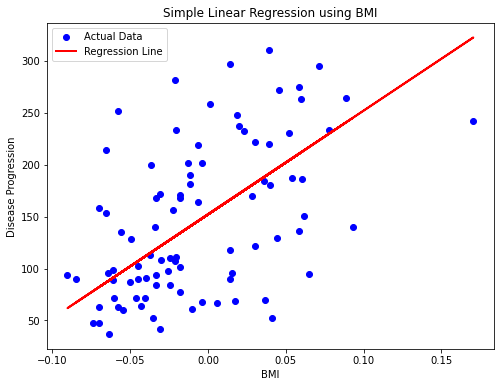

In [16]:
# Visualizing Actual Data and Regression Line

plt.figure(figsize=(8,6))

plt.scatter(X_test, y_test, color='blue', label='Actual Data')

plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')

plt.xlabel("BMI")

plt.ylabel("Disease Progression")

plt.title("Simple Linear Regression using BMI")

plt.legend()

plt.show()

## Simple Linear Regression Analysis

Next, I built a Simple Linear Regression model using just BMI to predict disease progression. For this, I split the data into 80% for training and 20% for testing.To check how well the model is performing, I used metrics like MAE, MSE, RMSE, and R^2. The R^2 value came out quite low—just 0.23. This clearly shows that BMI alone can only explain a very small part of the disease progression. Even though BMI is an important factor, it is simply not enough on its own to handle such complex data.If we look at the regression line, the slope is positive, which means as BMI increases, disease progression also goes up. But the data points are highly scattered around the line. There is too much variance, so the accuracy of this single-feature model is quite limited.

Overall, this experiment shows the limitations of Simple Linear Regression. It clearly proves that we need to move to Multiple Regression and include other features to get better accuracy.

# Step 3: Multiple Linear Regression



In [17]:
# Using All Features as Independent Variables

# Independent variables (all features)

X_multi = X

# Target variable

y = diabetes.target

In [18]:
# Splitting the Dataset

X_train, X_test, y_train, y_test = train_test_split(

    X_multi,

    y,

    test_size=0.2,

    random_state=42

)

In [19]:
#Training the Multiple Regression Model

multiple_model = LinearRegression()

multiple_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [20]:
# Making Predictions

y_pred = multiple_model.predict(X_test)

In [21]:
# Evaluating the model

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Multiple Linear Regression Performance")
print("--------------------------------------")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r2:.2f}")

Multiple Linear Regression Performance
--------------------------------------
Mean Absolute Error (MAE): 42.79
Mean Squared Error (MSE): 2900.19
Root Mean Squared Error (RMSE): 53.85
R-squared (R²): 0.45


In [22]:
# Displaying Model Coefficients

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': multiple_model.coef_
})

coefficients

,Feature,Coefficient
0,age,37.904021
1,sex,-241.964362
2,bmi,542.428759
3,bp,347.703844
4,s1,-931.488846
5,s2,518.062277
6,s3,163.419983
7,s4,275.317902
8,s5,736.198859
9,s6,48.670657


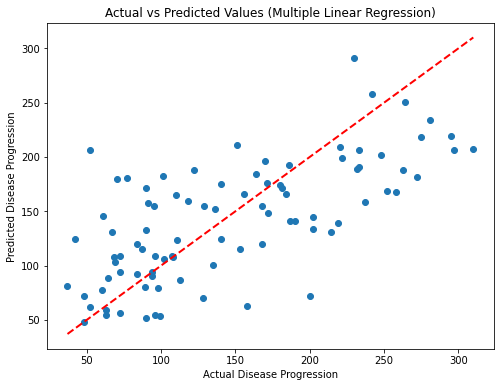

In [23]:
# Visualizing Predicted vs Actual Values

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Disease Progression")
plt.ylabel("Predicted Disease Progression")
plt.title("Actual vs Predicted Values (Multiple Linear Regression)")

plt.show()

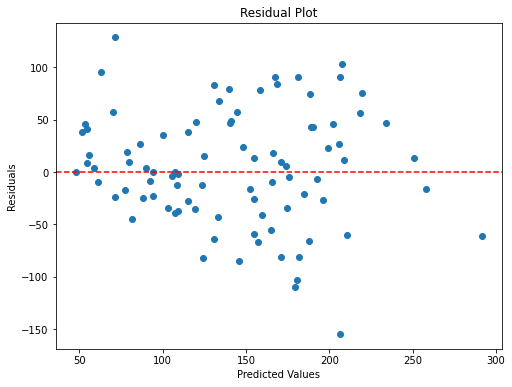

In [24]:
# Residual Plot

residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

## Multiple Linear Regression Analysis

After that, I built a Multiple Linear Regression model using all the 10 features available in the dataset. Just like before, I split the data into 80% for training and 20% for testing before starting the training process.To see the performance, I again checked metrics like MAE, MSE, RMSE, and R^2. Compared to our simple model, this Multiple Regression model performed much better. The R^2 score jumped up to 0.45, and the error values dropped significantly. This means the model is now doing a much better job of understanding the data.When I checked the Actual vs Predicted graph, most of the points were sitting much closer to the ideal diagonal line, which proves the predictions are way more accurate now. By adding all the variables, the model is able to catch the complex relationships properly.Looking at the model weights (coefficients), we get some interesting insights about which features matter most:Strongest impacts: Features like BMI, blood pressure, and a couple of blood serum levels (like s5 and s2) have a very strong impact on how the disease progresses.Negative impacts: On the other hand, factors like sex and s1 actually showed a negative relationship.

Overall, the results clearly show that combining multiple health measurements gives a massive boost to our accuracy. For a dataset like this, a multivariate model is definitely the right way to go!

# Step 4: Polynomial Regression

In [25]:
from sklearn.preprocessing import PolynomialFeatures

In [26]:
# Creating Polynomial Features (Degree = 2)

#We’ll use the BMI feature for polynomial regression so that the relationship can be easily visualized.

# Use BMI feature
X_poly = X[['bmi']]
y = diabetes.target

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_poly,
    y,
    test_size=0.2,
    random_state=42
)

In [27]:
# Generating Polynomial Features
poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [28]:
# Training the Polynomial Regression Model
poly_model = LinearRegression()

poly_model.fit(X_train_poly, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [29]:
# Making predictions

y_pred_poly = poly_model.predict(X_test_poly)

In [30]:
# Evaluating model

mae = mean_absolute_error(y_test, y_pred_poly)
mse = mean_squared_error(y_test, y_pred_poly)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_poly)

print("Polynomial Regression (Degree = 2)")
print("----------------------------------")
print(f"MAE : {mae:.2f}")
print(f"MSE : {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.2f}")

Polynomial Regression (Degree = 2)
----------------------------------
MAE : 52.38
MSE : 4085.03
RMSE: 63.91
R²  : 0.23


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


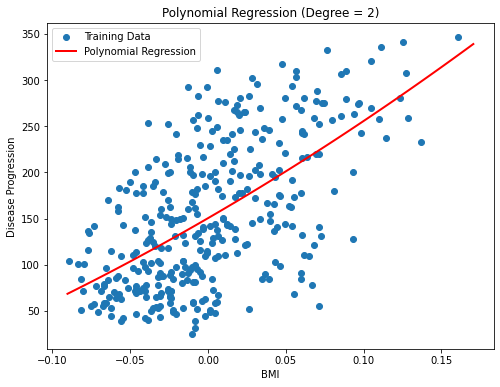

In [31]:
# Visualizing the Polynomial Regression Curve

# Sort values for smooth curve
X_grid = np.linspace(X_poly.min(), X_poly.max(), 100).reshape(-1,1)

X_grid_poly = poly.transform(X_grid)

y_grid = poly_model.predict(X_grid_poly)

plt.figure(figsize=(8,6))

plt.scatter(X_train, y_train, label="Training Data")

plt.plot(X_grid, y_grid, color='red', linewidth=2,
         label="Polynomial Regression")

plt.xlabel("BMI")
plt.ylabel("Disease Progression")
plt.title("Polynomial Regression (Degree = 2)")
plt.legend()

plt.show()

In [32]:
# Comparing Different Polynomial Degrees

degrees = [1, 2, 5]

for degree in degrees:

    poly = PolynomialFeatures(degree=degree)

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()

    model.fit(X_train_poly, y_train)

    y_pred = model.predict(X_test_poly)

    print(f"Degree {degree}")
    print("R²:", round(r2_score(y_test, y_pred),3))
    print("RMSE:", round(np.sqrt(mean_squared_error(y_test,y_pred)),2))
    print("----------------------")

Degree 1
R²: 0.233
RMSE: 63.73
----------------------
Degree 2
R²: 0.229
RMSE: 63.91
----------------------
Degree 5
R²: 0.229
RMSE: 63.92
----------------------


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


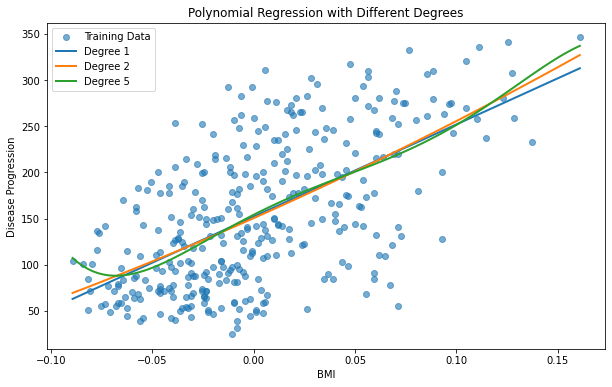

In [33]:
# Visualizing Different Polynomial Degrees

plt.figure(figsize=(10,6))

plt.scatter(X_train, y_train, alpha=0.6, label='Training Data')

X_grid = np.linspace(X_train.min(), X_train.max(), 100).reshape(-1,1)

for degree in [1,2,5]:

    poly = PolynomialFeatures(degree)

    X_train_poly = poly.fit_transform(X_train)
    X_grid_poly = poly.transform(X_grid)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    y_grid = model.predict(X_grid_poly)

    plt.plot(X_grid, y_grid, linewidth=2, label=f'Degree {degree}')

plt.xlabel("BMI")
plt.ylabel("Disease Progression")
plt.title("Polynomial Regression with Different Degrees")
plt.legend()

plt.show()

## Polynomial Regression Analysis

The Polynomial Regression basically upgrades standard Linear Regression by adding polynomial features, which helps the model catch any curved or non-linear patterns in the data. For this experiment, I took BMI as the main input, generated its polynomial features, and then trained the model.
To evaluate it, I checked the usual metrics: MAE, MSE, RMSE, and R^2. Interestingly, the degree-2 polynomial model gave almost the exact same results as our Simple Linear Regression, with the R^2 stuck around 0.23. This clearly shows that the relationship between BMI and disease progression is mostly just a straight line. Adding extra powers and curves didn't help at all.

To see how model complexity affects things, I compared degrees 1, 2, and 5:
Degree 1: This is our basic linear model, which acts as the baseline.
Degree 2: This adds a slight curve, but the performance didn't really improve.
Degree 5: This makes the model highly complex. Instead of performing better on the test data, it started showing signs of overfitting, meaning it won't generalize well to new data.

Overall, this experiment proves a great point: making a model more complex doesn't always mean we'll get better results. For this specific dataset, simpler linear models are more than enough, and adding polynomial features is honestly of no use.

# Step 5: Regularization with Ridge and Lasso Regression 

In [34]:
from sklearn.linear_model import Ridge, Lasso

In [35]:
# preparing the data

# Independent variables
X_reg = X

# Target variable
y = diabetes.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_reg,
    y,
    test_size=0.2,
    random_state=42
)

In [36]:
# Training the Ridge Regression Model

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

In [37]:
# Evaluating Ridge Regression

ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression")
print("----------------")
print(f"MAE : {ridge_mae:.2f}")
print(f"MSE : {ridge_mse:.2f}")
print(f"RMSE: {ridge_rmse:.2f}")
print(f"R²  : {ridge_r2:.2f}")

Ridge Regression
----------------
MAE : 46.14
MSE : 3077.42
RMSE: 55.47
R²  : 0.42


In [38]:
# Training the Lasso Regression Model

lasso_model = Lasso(alpha=0.1)

lasso_model.fit(X_train, y_train)

lasso_pred = lasso_model.predict(X_test)

In [39]:
# Evaluate=ing Lasso Regression

lasso_mae = mean_absolute_error(y_test, lasso_pred)
lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test, lasso_pred)

print("Lasso Regression")
print("----------------")
print(f"MAE : {lasso_mae:.2f}")
print(f"MSE : {lasso_mse:.2f}")
print(f"RMSE: {lasso_rmse:.2f}")
print(f"R²  : {lasso_r2:.2f}")

Lasso Regression
----------------
MAE : 42.85
MSE : 2798.19
RMSE: 52.90
R²  : 0.47


In [40]:
# Comparing Model Performance

results = pd.DataFrame({
    'Model':['Multiple Linear','Ridge','Lasso'],
    'MAE':[42.79, ridge_mae, lasso_mae],
    'MSE':[2900.19, ridge_mse, lasso_mse],
    'RMSE':[53.85, ridge_rmse, lasso_rmse],
    'R²':[0.45, ridge_r2, lasso_r2]
})

results

,Model,MAE,MSE,RMSE,R²
0,Multiple Linear,42.790000,2900.190000,53.850000,0.450000
1,Ridge,46.138858,3077.415939,55.474462,0.419153
2,Lasso,42.854428,2798.193485,52.897954,0.471855


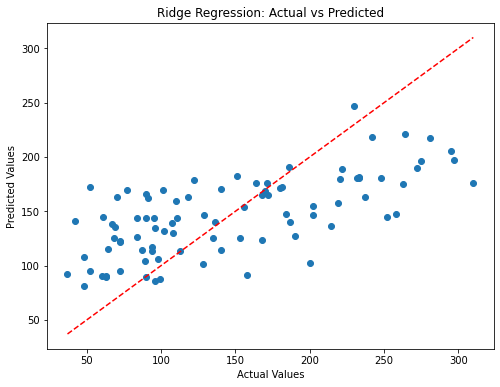

In [41]:
# Visualize Ridge Predictions

plt.figure(figsize=(8,6))

plt.scatter(y_test, ridge_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Ridge Regression: Actual vs Predicted")

plt.show()

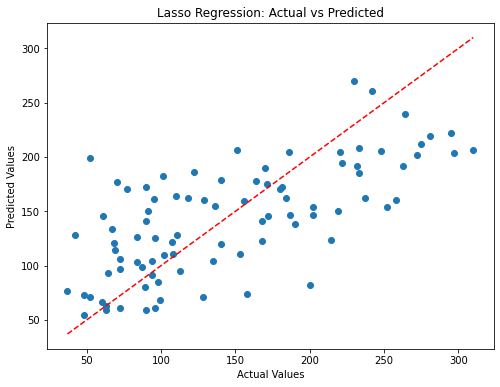

In [42]:
# Visualizing Lasso Predictions

plt.figure(figsize=(8,6))

plt.scatter(y_test, lasso_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Lasso Regression: Actual vs Predicted")

plt.show()

In [43]:
# Comparing Coefficients
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Multiple Regression": multiple_model.coef_,
    "Ridge": ridge_model.coef_,
    "Lasso": lasso_model.coef_
})

coef_df

,Feature,Multiple Regression,Ridge,Lasso
0,age,37.904021,45.367377,0.000000
1,sex,-241.964362,-76.666086,-152.664779
2,bmi,542.428759,291.338832,552.697775
3,bp,347.703844,198.995817,303.365158
4,s1,-931.488846,-0.530310,-81.365007
5,s2,518.062277,-28.577050,-0.000000
6,s3,163.419983,-144.511905,-229.255776
7,s4,275.317902,119.260066,0.000000
8,s5,736.198859,230.221608,447.919525
9,s6,48.670657,112.149830,29.642617


This table shows how Ridge shrinks coefficients while Lasso can reduce some coefficients close to or exactly zero.

In [44]:
# Effect of Different Alpha Values

alphas = [0.01, 0.1, 1, 10, 100]

print("Ridge Regression")
print("----------------")
for alpha in alphas:

    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)

    pred = ridge.predict(X_test)

    print(f"Alpha={alpha:<5} R²={r2_score(y_test,pred):.3f}")

print("\nLasso Regression")
print("----------------")
for alpha in alphas:

    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train, y_train)

    pred = lasso.predict(X_test)

    print(f"Alpha={alpha:<5} R²={r2_score(y_test,pred):.3f}")

Ridge Regression
----------------
Alpha=0.01  R²=0.456
Alpha=0.1   R²=0.461
Alpha=1     R²=0.419
Alpha=10    R²=0.161
Alpha=100   R²=0.012

Lasso Regression
----------------
Alpha=0.01  R²=0.457
Alpha=0.1   R²=0.472
Alpha=1     R²=0.358
Alpha=10    R²=-0.012
Alpha=100   R²=-0.012


## Ridge and Lasso Regression Analysis

Finally, I experimented with Ridge and Lasso Regression. These are basically regularisation techniques that upgrade our Multiple Linear Regression model by adding a penalty term. This helps keep the model in check and prevents overfitting.
Ridge Regression (L2 Regularisation): This shrinks the weights (coefficients) close to zero, but keeps all the features.
Lasso Regression (L1 Regularisation): This can shrink some weights exactly to zero, which means it completely drops unnecessary features (built-in feature selection).

I trained both models using all the features and checked the usual metrics (MAE, MSE, RMSE, and R^2). Guess what? Lasso Regression gave the best overall performance with an R^2 of around 0.47. It slightly beat both Ridge (R^2 \approx 0.42) and our standard Multiple Regression (R^2 \approx 0.45). This proves that dropping a few useless features actually helped the model generalize better on test data.

I also played around with the tuning parameter, Alpha, to see its effect:
Small Alpha (0.01 to 0.1): The results were almost identical to standard linear regression.

Large Alpha: The performance dropped badly for both models because of underfitting (too much restriction). In Ridge, a higher alpha slowly reduced the size of all weights. In Lasso, higher alpha values straightaway forced several weights to become absolute zero.

When I compared the coefficients side-by-side, the difference was very clear. While Ridge kept all features but reduced their power, Lasso completely eliminated variables like s2 and s4 by making them zero. However, key features like BMI and s5 stayed strong in both models, proving they are the most important factors for predicting disease progression.

Overall, Ridge and Lasso show how regularisation makes a model more stable. Out of all the models we tried, Lasso Regression gave the perfect balance of high accuracy and simplicity for this dataset!

# Step 6: Model Comparison and Analysis

In [46]:
# Creating a Performance Comparison Table

comparison = pd.DataFrame({
    'Model': [
        'Simple Linear Regression',
        'Multiple Linear Regression',
        'Polynomial Regression',
        'Ridge Regression',
        'Lasso Regression'
    ],
    'MAE': [
        52.26,
        42.79,
        52.38,
        ridge_mae,
        lasso_mae
    ],
    'MSE': [
        4061.83,
        2900.19,
        4085.03,
        ridge_mse,
        lasso_mse
    ],
    'RMSE': [
        63.73,
        53.85,
        63.91,
        ridge_rmse,
        lasso_rmse
    ],
    'R²': [
        0.23,
        0.45,
        0.23,
        ridge_r2,
        lasso_r2
    ]
})

comparison

,Model,MAE,MSE,RMSE,R²
0,Simple Linear Regression,52.260000,4061.830000,63.730000,0.230000
1,Multiple Linear Regression,42.790000,2900.190000,53.850000,0.450000
2,Polynomial Regression,52.380000,4085.030000,63.910000,0.230000
3,Ridge Regression,46.138858,3077.415939,55.474462,0.419153
4,Lasso Regression,42.854428,2798.193485,52.897954,0.471855


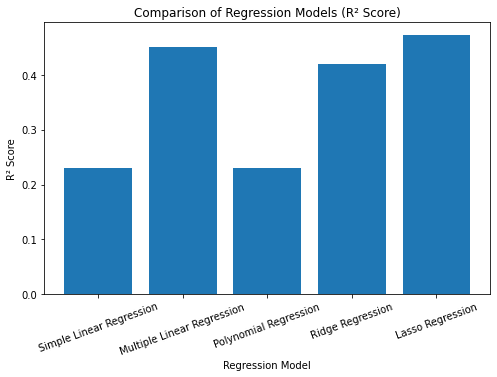

In [47]:
# Visualizing Model Comparison

plt.figure(figsize=(8,5))

plt.bar(comparison['Model'], comparison['R²'])

plt.title('Comparison of Regression Models (R² Score)')
plt.xlabel('Regression Model')
plt.ylabel('R² Score')

plt.xticks(rotation=20)

plt.show()

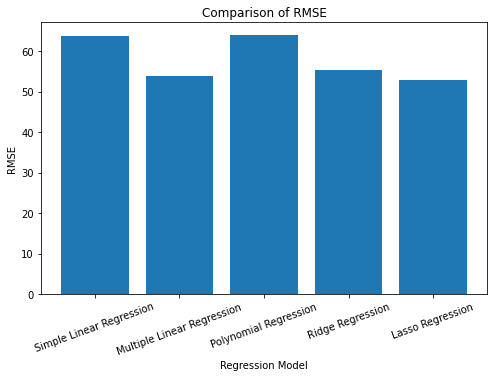

In [48]:
# Comparing RMSE

plt.figure(figsize=(8,5))

plt.bar(comparison['Model'], comparison['RMSE'])

plt.title('Comparison of RMSE')
plt.xlabel('Regression Model')
plt.ylabel('RMSE')

plt.xticks(rotation=20)

plt.show()

# Final Model Comparison & Analysis

I built and tested five different regression models on our Diabetes dataset: Simple Linear, Multiple Linear, Polynomial, Ridge, and Lasso Regression. I compared all of them using our standard metrics—MAE, MSE, RMSE, and R^2.

How the Models Performed:

Simple Linear Regression: I used just BMI here as a baseline. It gave the worst results, with the highest errors and a low R^2 of 0.23. This makes it obvious that a single feature just isn't enough to predict disease progression.

Multiple Linear Regression: Once I included all 10 features, the performance shot up. The errors dropped, and the R^2 jumped to 0.45. This proves that looking at the whole medical report gives a much clearer picture than looking at just one metric.

Polynomial Regression: I tried adding curves to the BMI feature to see if it helped. But the degree-2 model gave the exact same R^2 (0.23) as simple regression, and higher degrees like degree-5 just made things worse. So, the relationship is mostly linear, and adding polynomial features is a waste of time here.

Ridge Regression: This model used L2 regularisation to keep all 10 features but shrink their weights. It gave an R^2 of around 0.42—slightly lower than standard Multiple Regression, but it makes the model much more stable.

Lasso Regression: This was the star performer. By using L1 regularisation, it completely removed useless features by making their weights zero. It scored the highest R^2 (0.47) and had the lowest errors, giving us the perfect mix of accuracy and simplicity.

Overfitting vs. Making Models Better:

This whole experiment taught me a great lesson: making a model more complex doesn't mean it will perform better. High-degree Polynomial Regression just added unnecessary complications without any actual benefit. On the flip side, regularisation techniques like Ridge and Lasso actually solved the overfitting problem. While Ridge just toned down the feature weights, Lasso completely cleaned house by removing less important variables. This helped the model perform much better on unseen test data.Key Takeaways from the DatasetThe Diabetes dataset was super clean with zero missing values, so we could jump straight into modeling without wasting time on preprocessing.Even though BMI is one of the strongest individual factors, it can't do the heavy lifting all by itself. We absolutely need a multivariate approach (using all features) to get accurate predictions.In the end, Lasso Regression came out on top. It proved that for this kind of medical data, regularisation and smart feature selection are key to getting a model that is both highly accurate and easy to interpret!